## Overview

The purpose of this notebook is to provide a standardised testing ground for different algorithms on a perfect inductive curve

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as so
import scipy.signal as ss
import matplotlib.patches as patches
import matplotlib.lines as mlines
import torch 
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

/home/josh-edmundson/Documents/SIMsalabim-installs/pySIMsalabim/Notebooks/Projects/Den RT/4 Case Algorithm Testing/../../../../pySIMsalabim/aux_funcs/time_domain_DRT.py:743: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("Residual $J - \hat{J}_{\\text{cap}}$")


### Analytic Curve - Distinct Discrete Decay Events

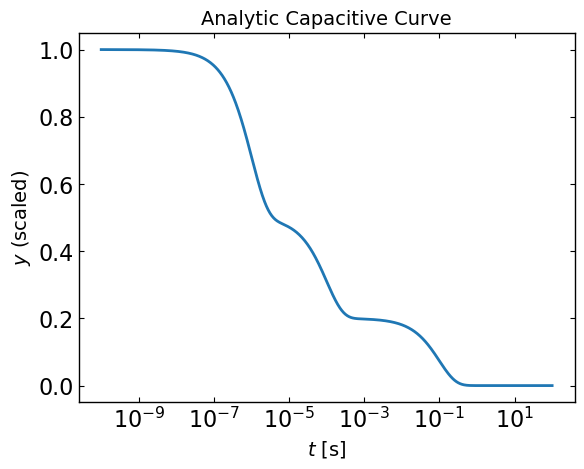

In [85]:
# Generate an array of time values of length N
t_min = 1e-10
t_max = 1e2
time = np.geomspace(t_min, t_max, 1000)
time_ppd = int(np.log10(t_max/t_min))

# Generate array of tau values of length M such that tau_ppd ~ time_ppd (ppd - points per decade)
tau_min = (time[1]-time[0])/np.pi   # Selected based on Nyquist spacing
tau_max = t_max/(2*np.pi)   # Selected based on Nyquist spacing
tau_dec = int(np.log10(tau_max/tau_min))
tau_values = np.geomspace(t_min/np.pi, t_max/(2*np.pi), tau_dec*time_ppd)

# Generate the analytic curve
analytic_U = [5, 3, 2]
analytic_tau = [1e-6, 1e-4, 1e-1]
analytic_y = drt.predict_y(time, analytic_U, analytic_tau)
analytic_y_scaled = (analytic_y - analytic_y.min())/(analytic_y.max() - analytic_y.min())

# Plot the data 
plt.plot(time, analytic_y_scaled)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$y$ (scaled)')
plt.title("Analytic Capacitive Curve")
plt.show()

### Algorithms


#### PyTorch Checkerboard

In [86]:
pytorch_checkerboard = drt.checkerboard_fit(time, analytic_y_scaled, tau_values, max_fit_iter=100, checkerboard_iter=100)

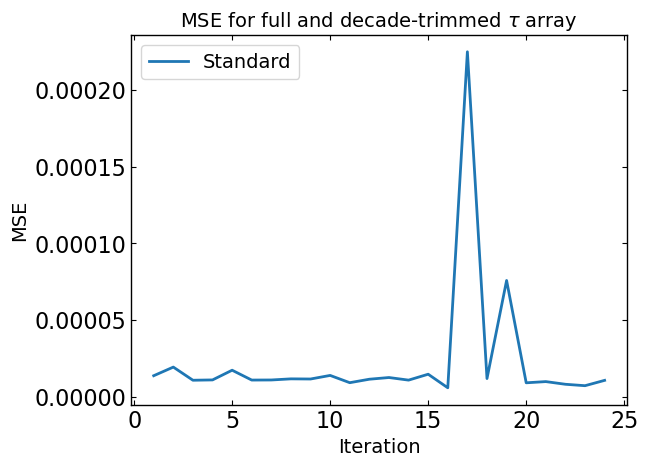

In [87]:
# pytorch MSE
torch_MSE = [np.mean((fit.y - analytic_y_scaled)**2) for fit in pytorch_checkerboard]

plt.plot(range(1, len(pytorch_checkerboard)+1), torch_MSE, label='Standard')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title("MSE for full and decade-trimmed $\\tau$ array ")
plt.legend()
plt.show()

In [88]:
torch_min_fit = pytorch_checkerboard[np.argmin(torch_MSE)]

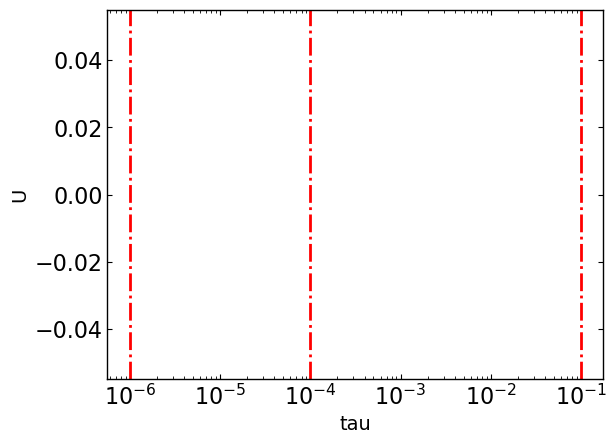

In [89]:
# Plot fitted curves 
plt.plot(tau_values, torch_min_fit.U)
for tau in analytic_tau:
    plt.axvline(tau, color='red', linestyle='-.')
plt.xlabel("tau")
plt.ylabel('U')
plt.xscale('log')

#### OSQP Checkerboard 

In [90]:
osqp_checkerboard = drt.osqp_checkerboard_fit(time, analytic_y_scaled, tau_values, checkerboard_iters=100)

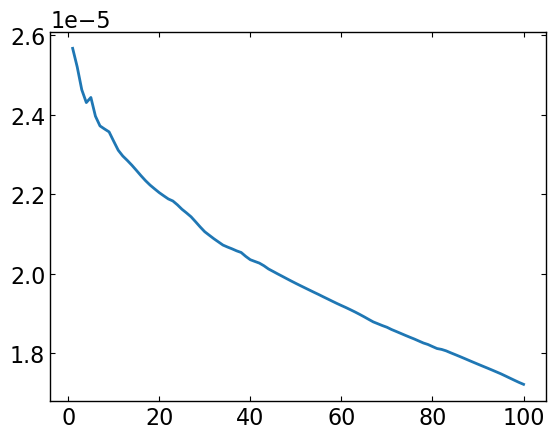

In [91]:
MSE_values_osqp = [fit.cost for fit in osqp_checkerboard]
plt.plot(range(1, len(MSE_values_osqp)+1), MSE_values_osqp)

In [92]:
osqp_checkerboard_min = osqp_checkerboard[np.argmin(MSE_values_osqp)]

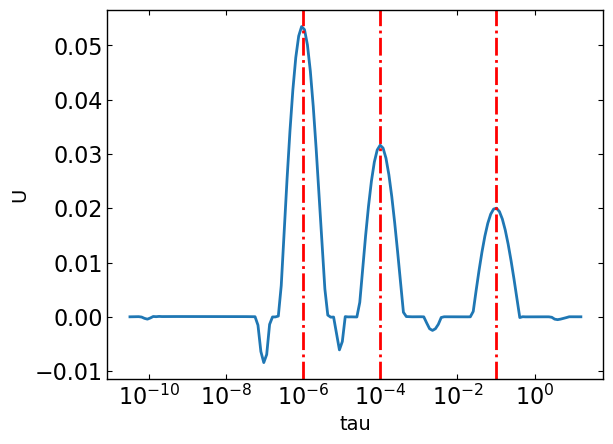

In [93]:
plt.plot(tau_values, osqp_checkerboard_min.U)
for tau in analytic_tau:
    plt.axvline(tau, color='red', linestyle='-.')
plt.xlabel("tau")
plt.ylabel('U')
plt.xscale('log')

### Analytic Curve - Distinct Continuous Decay Events
Assuming, in an experimental world, decay events are unlikely to be discrete, but would instead have some more complex interaction. To test how the fitting function does against more complex signals, we'll assume several decay events that follow the Curie-von Schweidler relation, namely $I(t) \propto t^{-n}$.

Having then given this a go, I've decided to use Gaussian distributions instead, as I think the fitting algorithms struggle to deal with the fact this tends to infinity whenever there's a root.

In [94]:
# Define a function that simulates a Curie-von Schweidler response of order n at time tau
def cs_current(time, coeff, n):
    return coeff*time**(-n)

In [95]:
# Define a function to give a gaussian distribution of lifetimes about a central lifetime tau on a logarithmic scale
def log_gaussian(tau, mu, sig):
    return 1/(sig*np.sqrt(2*np.pi))*np.exp(-(np.log10(tau/mu))**2/(2*sig**2))

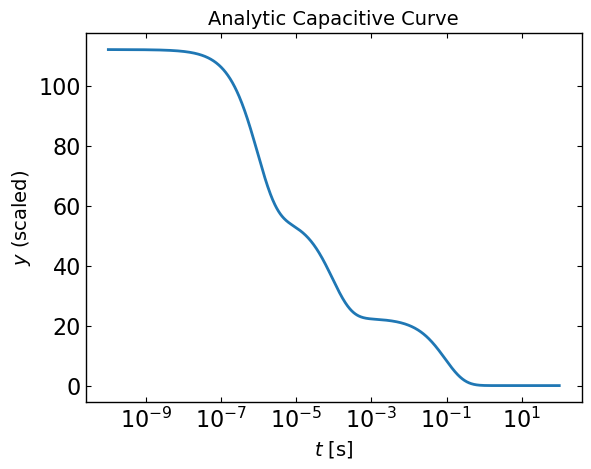

In [96]:
# Generate an array of time values of length N
t_min = 1e-10
t_max = 1e2
time = np.geomspace(t_min, t_max, 1000)
time_ppd = int(np.log10(t_max/t_min))

# Generate array of tau values of length M such that tau_ppd ~ time_ppd (ppd - points per decade)
tau_min = t_min/np.pi   # Selected based on Nyquist spacing
tau_max = t_max/(2*np.pi)   # Selected based on Nyquist spacing
tau_dec = int(np.log10(tau_max/tau_min))
tau_values = np.geomspace(t_min/np.pi, t_max/(2*np.pi), tau_dec*time_ppd)

# Generate the analytic curve
gaussian_coeffs = [5, 3, 2]
gaussian_peaks = [1e-6, 1e-4, 1e-1] # These now correspond to when decay events begin
analytic_U = np.sum([gaussian_coeffs[i]*log_gaussian(tau_values, gaussian_peaks[i], 0.2) for i in range(len(gaussian_coeffs))], axis=0)
analytic_y = drt.predict_y(time, analytic_U, tau_values)
analytic_y_scaled = (analytic_y - analytic_y.min())/(analytic_y.max() - analytic_y.min())

# Plot the data 
plt.plot(time, analytic_y)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$y$ (scaled)')
plt.title("Analytic Capacitive Curve")
plt.show()

### Algorithms

#### Pytorch

In [97]:
checkerboard_iter = 100
pytorch_checkerboard = drt.checkerboard_fit(time, analytic_y_scaled, tau_values, max_fit_iter=100, checkerboard_iter=checkerboard_iter)

In [98]:
# Calculate scaling constants
y_inf = analytic_y[-1]
y_translated = analytic_y - y_inf
y_translated_max = np.max(y_translated)
y_translated_min = np.min(y_translated)
R = y_translated_max - y_translated_min

In [99]:
# Scale up the MSE, find the best fitting model, and display below
torch_MSE = R**2*np.array([fit.cost for fit in pytorch_checkerboard])
torch_min_fit = pytorch_checkerboard[np.argmin(torch_MSE)]

[]

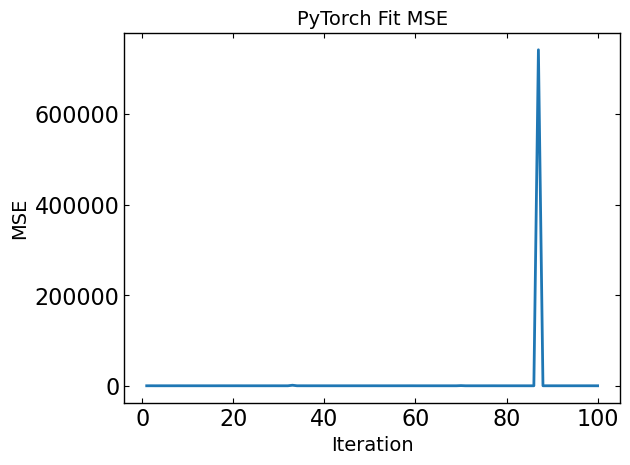

In [100]:
# Plot the error 
plt.plot(range(1, checkerboard_iter+1), torch_MSE)
plt.xlabel('Iteration')
plt.ylabel("MSE")
plt.title("PyTorch Fit MSE")
plt.plot()

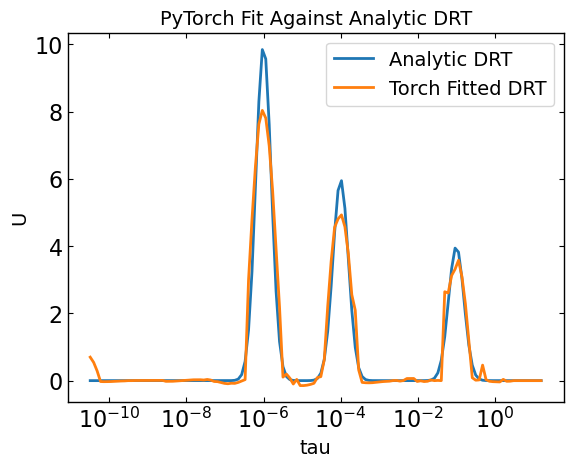

In [101]:
torch_min_fit = pytorch_checkerboard[np.argmin(torch_MSE)]

# Plot fitted curves 
plt.plot(tau_values, analytic_U, label='Analytic DRT')
plt.plot(tau_values, R*torch_min_fit.U, label='Torch Fitted DRT')
plt.xlabel("tau")
plt.ylabel('U')
plt.xscale('log')
plt.title("PyTorch Fit Against Analytic DRT")
plt.legend()
plt.show()

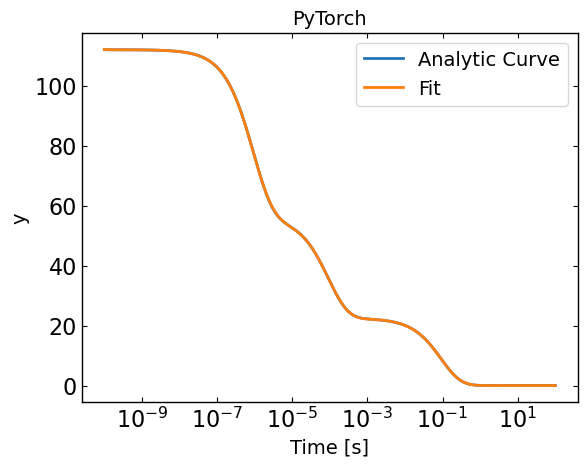

In [102]:
# Plot the two curves against each other
plt.plot(time, analytic_y, label='Analytic Curve')
plt.plot(time, R*torch_min_fit.y + y_translated_min + y_inf, label='Fit')
# plt.plot(time, drt.predict_y(time, R*torch_min_fit.U, tau_values, y_translated_min + y_inf))
plt.xlabel('Time [s]')
plt.ylabel('y')
plt.title('PyTorch')
plt.xscale('log')
plt.legend()
plt.show()

In [103]:
def r2_error(data, model):
    SSres = np.sum((data - model)**2)
    SStot = np.sum((data - np.mean(data))**2)
    return 1 - SSres/SStot

In [104]:
max_iters = []
y_errors = []
U_errors = []

checkerboard_iters=1000

torch_checkerboard = drt.checkerboard_fit(time, analytic_y_scaled, tau_values, max_fit_iter=100, checkerboard_iter=checkerboard_iters)

In [105]:
for i in range(1, checkerboard_iters-1):
    fit = torch_checkerboard[i-1]
    y_error_R2 = r2_error(analytic_y, (R*fit.y + y_inf + y_translated_min))
    U_error_R2 = r2_error(analytic_U, R*fit.U)

    max_iters.append(i+1)
    y_errors.append(y_error_R2)
    U_errors.append(U_error_R2)

    if i % 50 == 0:
        print(f"{i}")

50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950


(0.0, 1.1)

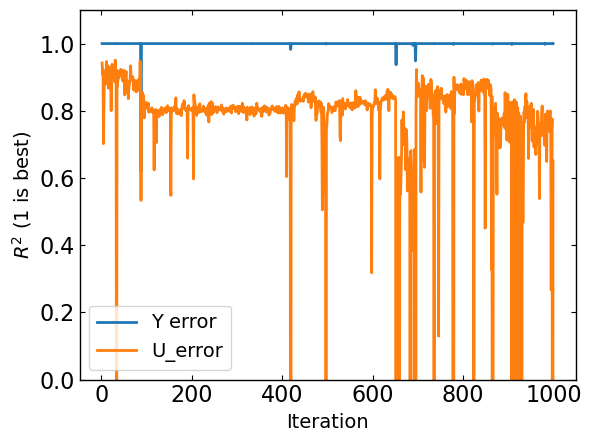

In [106]:
# Test how the fits do over time
plt.plot(max_iters, y_errors, label='Y error')
plt.plot(max_iters, U_errors, label='U_error')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel("$R^2$ (1 is best)")
plt.ylim(0, 1.1)

#### OSQP Checkerboard Algorithm

In [107]:
checkerboard_iters = 2
osqp_checkerboard = drt.osqp_checkerboard_fit(time, analytic_y_scaled, tau_values, checkerboard_iters=checkerboard_iters)

In [108]:
# Scale up the MSE, find the best fitting model, and display below
osqp_MSE = R**2*np.array([fit.cost for fit in osqp_checkerboard])
osqp_min_fit = osqp_checkerboard[np.argmin(osqp_MSE)]

[]

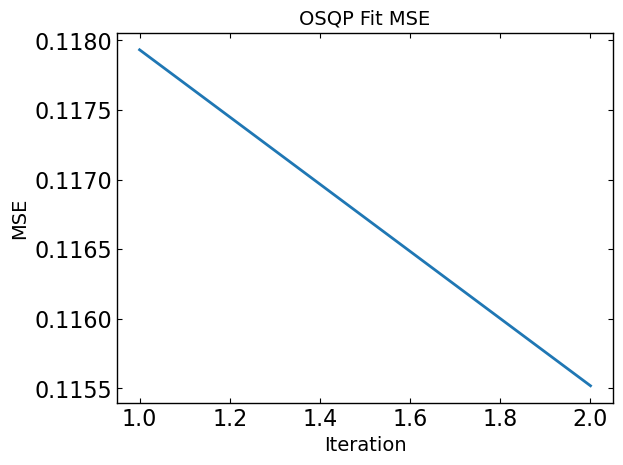

In [109]:
# Plot the error 
plt.plot(range(1, checkerboard_iters+1), osqp_MSE)
plt.xlabel('Iteration')
plt.ylabel("MSE")
plt.title("OSQP Fit MSE")
plt.plot()

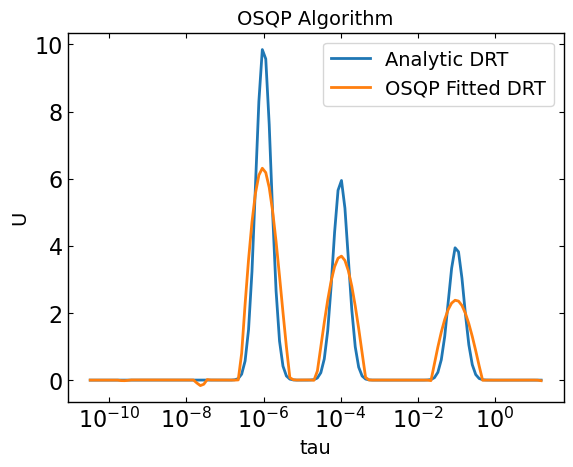

In [110]:
# Plot fitted curves 
plt.plot(tau_values, analytic_U, label='Analytic DRT')
plt.plot(tau_values, R*osqp_min_fit.U, label='OSQP Fitted DRT')
plt.xlabel("tau")
plt.ylabel('U')
plt.xscale('log')
plt.title("OSQP Algorithm")
plt.legend()
plt.show()

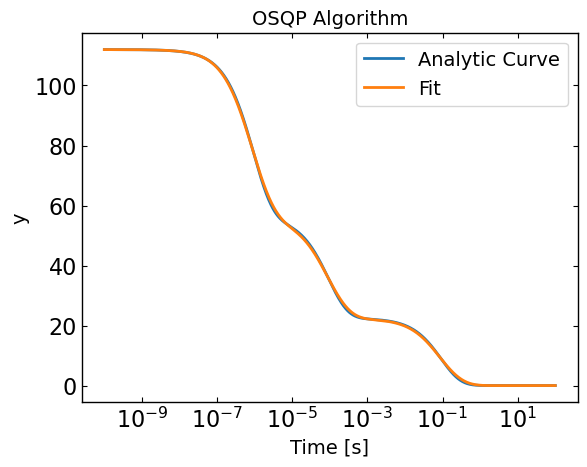

In [111]:
# Plot the two curves against each other
plt.plot(time, analytic_y, label='Analytic Curve')
plt.plot(time, R*osqp_min_fit.y + y_translated_min + y_inf, label='Fit')
# plt.plot(time, drt.predict_y(time, R*torch_min_fit.U, tau_values, y_translated_min + y_inf))
plt.xlabel('Time [s]')
plt.ylabel('y')
plt.title('OSQP Algorithm')
plt.xscale('log')
plt.legend()
plt.show()

In [112]:
# Test how y error and DRT error change with number of max iterations for OSQP
max_iters = []
y_errors = []
U_errors = []

osqp_checkerboard = drt.osqp_checkerboard_fit(time, analytic_y_scaled, tau_values, checkerboard_iters=1000)

for i in range(1, 1001):
    fit = osqp_checkerboard[i-1]
    y_error_R2 = r2_error(analytic_y, (R*fit.y + y_inf + y_translated_min))
    U_error_R2 = r2_error(analytic_U, R*fit.U)

    max_iters.append(i+1)
    y_errors.append(y_error_R2)
    U_errors.append(U_error_R2)

    if i % 50 == 0:
        print(f"{i}")

50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000


Text(0, 0.5, '$R^2$ (1 is best)')

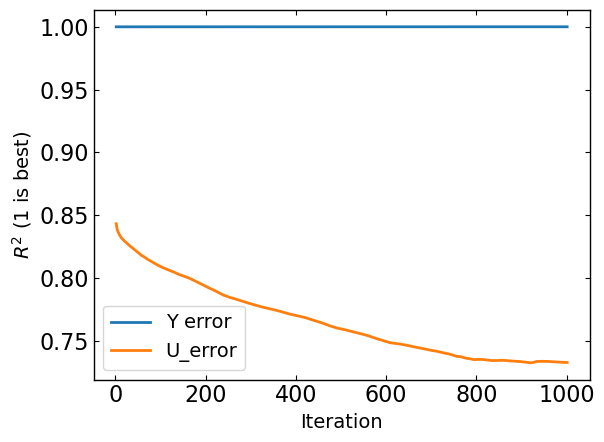

In [113]:
plt.plot(max_iters, y_errors, label='Y error')
plt.plot(max_iters, U_errors, label='U_error')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel("$R^2$ (1 is best)")

#### OSQP Un-Bounded Linear Fit

In [114]:
# Try osqp cap fit for a single bounded iteration
single_osqp_fit = drt.osqp_linear_fit(time, analytic_y_scaled, tau_values)

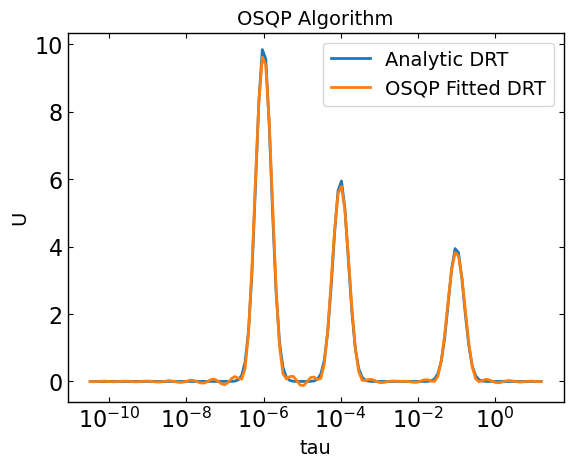

In [115]:
# Plot fitted curves 
plt.plot(tau_values, analytic_U, label='Analytic DRT')
plt.plot(tau_values, R*single_osqp_fit.U, label='OSQP Fitted DRT')
plt.xlabel("tau")
plt.ylabel('U')
plt.xscale('log')
plt.title("OSQP Algorithm")
plt.legend()
plt.show()

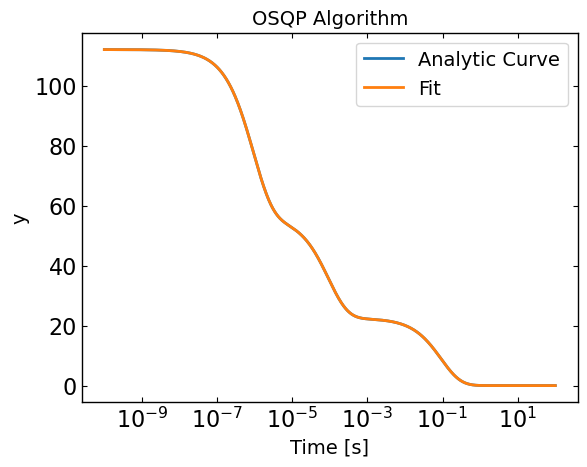

In [116]:
# Plot the two curves against each other
plt.plot(time, analytic_y, label='Analytic Curve')
plt.plot(time, drt.predict_y(time, R*single_osqp_fit.U, tau_values, y_translated_min + y_inf), label='Fit')
# plt.plot(time, drt.predict_y(time, R*torch_min_fit.U, tau_values, y_translated_min + y_inf))
plt.xlabel('Time [s]')
plt.ylabel('y')
plt.title('OSQP Algorithm')
plt.xscale('log')
plt.legend()
plt.show()